# Pipeline DINO + MedSAM amélioré (Pancreas MSD)

**Problème de base :** DINO hallucine des tumeurs ; MedSAM suit et segmente n'importe quoi ; les scans sans tumeur sont mal gérés.

**Solution : 3 portes (gates) ajoutées avant / autour de MedSAM :**

1. **G1 — ROI pancréas.** Un UNet 2D entraîné ici-même sur les labels `mask==1` du MSD restreint la zone de recherche.
2. **G2 — filtre de candidats.** On ne garde que les boxes DINO qui recouvrent suffisamment le pancréas. Option : **dual-prompt** (score DINO tumor minus score DINO sur distracteurs, pour émuler un *negative prompt*).
3. **G3 — décision no-tumor.** Seuil τ calibré sur le split val, et vérification optionnelle du crop candidat par Gemini.

**Config v2** (après ablation v1 : sens=0.73, DICE=0.34 — trop strict) :
- UNet entraîné en Tversky loss (β=0.7) à 384 px, 30 epochs → ROI plus généreuse
- `PANCREAS_DILATION_PX = 35` (vs 15)
- `MIN_PANCREAS_OVERLAP = 0.05` (vs 0.10)
- `MIN_CENTER_IN_MASK = False` (n'exige plus le centroïde dans le ROI)
- `CLIP_MASK_TO_PANCREAS_ROI = False` (ne rogne plus le masque MedSAM final)

Le UNet pancréas est **sauvegardé dans Drive** (`work_dirs/pancreas_unet/best.pt`) — le premier run entraîne, les suivants chargent.

## 0. Setup Colab (clone + deps + symlinks Drive)

Premier lancement : ~2 min (install deps) + monter Drive. Relancer la cellule est idempotent.

In [1]:
# === Colab bootstrap ================================================
try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    import os, sys, subprocess
    REPO = '/content/INF8225_Projet'
    if not os.path.isdir(REPO):
        subprocess.check_call(['git', 'clone', '--depth', '1', '--branch', 'temp',
            'https://github.com/moradBMH/INF8225_Projet.git', REPO])
    if os.getcwd() != REPO:
        os.chdir(REPO)
    if REPO not in sys.path:
        sys.path.insert(0, REPO)

    from colab.setup import setup
    setup()
else:
    print('Local run — skipping Colab setup. Make sure data/ and work_dirs/ are populated.')

→ detect GPU
✓ deps already installed, skipping
✓  /content/INF8225_Projet/data already linked
✓  /content/INF8225_Projet/work_dirs already linked
✓  /content/INF8225_Projet/MedSAM/work_dir already linked
✓  /content/INF8225_Projet/grounding_dino_swin-t_pretrain_obj365_goldg_20231122_132602-4ea751ce.pth already linked

Project : /content/INF8225_Projet
Drive   : /content/drive/MyDrive/Projet_Medsam
Device  : Tesla T4
Torch   : 2.4.0+cu121

⚠  numpy was already loaded in this kernel before setup reinstalled it.
   Runtime → Restart session, then run your imports again
   (no need to rerun setup — deps are pinned on disk).


## 1. Imports & config override

Après `setup()`, les chemins dans `config.py` pointent vers les dossiers Drive via symlink. On charge tout.

In [2]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import torch

from agentic.dino_gemini_msd import (
    config, pancreas_roi, gating, calibrate, eval_improved, grounding_dino as gd, medsam,
)

print('CUDA available:', torch.cuda.is_available())
print('MSD root :', config.MSD_ROOT, config.MSD_ROOT.exists())
print('DINO cfg :', config.DINO_CONFIG, config.DINO_CONFIG.exists())
print('DINO ckpt:', config.DINO_CHECKPOINT, config.DINO_CHECKPOINT.exists())
print('MedSAM   :', config.MEDSAM_CHECKPOINT, config.MEDSAM_CHECKPOINT.exists())
print('UNet ckpt:', config.PANCREAS_CKPT, config.PANCREAS_CKPT.exists())

CUDA available: True
MSD root : /content/INF8225_Projet/data/MSD_pancreas True
DINO cfg : /content/INF8225_Projet/tumor_config_v3.py True
DINO ckpt: /content/INF8225_Projet/work_dirs/tumor_config_v3/best_coco_bbox_mAP_epoch_11.pth True
MedSAM   : /content/INF8225_Projet/MedSAM/work_dir/MedSAM/medsam_vit_b.pth True
UNet ckpt: /content/INF8225_Projet/work_dirs/pancreas_unet/best.pt True


## 2. Entraîner (ou charger) le UNet pancréas

Cible : `mask==1` dans les masques MSD. 4-level UNet (~1.9 M params à base=32).

**Hyperparams v2** (après ablation v1 décevante à DICE 0.41 / sens 0.73) :
- Input **384 px** (au lieu de 256)
- **30 epochs** (au lieu de 15)
- **Tversky loss** avec `β=0.7, α=0.3` → 2× pénalité FN vs FP → ROI plus généreuse, privilégie le recall (ce qu'on veut pour un gate)
- Augmentations : flip horizontal + bruit gaussien léger

- Premier run : entraîne ~10-15 min sur T4 et sauvegarde dans `work_dirs/pancreas_unet/best.pt` (Drive)
- Runs suivants : charge le checkpoint existant

Pour ré-entraîner, laisse `RETRAIN_UNET = True` ou supprime le `.pt`.

In [3]:
RETRAIN_UNET = False  # forcer le ré-entraînement avec Tversky + 384 px

# Hyperparams v2: input 384, 30 epochs, Tversky (β=0.7 → 2× pénalité FN, ROI plus généreuse)
if RETRAIN_UNET or not config.PANCREAS_CKPT.exists():
    print(f'Training pancreas UNet → {config.PANCREAS_CKPT}')
    train_info = pancreas_roi.train_pancreas_unet(
        train_json=config.MSD_ROOT / 'train.json',
        val_json=config.MSD_ROOT / 'val.json',
        data_root=config.MSD_ROOT,
        epochs=30,
        batch_size=6,            # 384 px + base=32 ⇒ ~3.5 GB VRAM @ bs=6 sur T4
        lr=1e-3,
        img_size=384,
        loss_name='tversky',
        tversky_beta=0.7,
        base_channels=32,
        save_path=config.PANCREAS_CKPT,
    )
    print('best val dice =', train_info.best_val_dice)
    # Drop the in-memory model so the fresh weights get loaded on next call
    pancreas_roi.reset_cache()
else:
    print(f'Loading cached pancreas UNet from {config.PANCREAS_CKPT}')
    unet = pancreas_roi.get_pancreas_unet()
    print('val dice at save time =', unet['val_dice'], ' img_size =', unet['img_size'])

Training pancreas UNet → /content/INF8225_Projet/work_dirs/pancreas_unet/best.pt
ep 00  train_loss=0.9484  val_dice=0.0825
ep 01  train_loss=0.8796  val_dice=0.0000
ep 02  train_loss=0.7519  val_dice=0.1291
ep 03  train_loss=0.6833  val_dice=0.0000
ep 04  train_loss=0.6399  val_dice=0.1689
ep 05  train_loss=0.6109  val_dice=0.2374
ep 06  train_loss=0.5814  val_dice=0.1776
ep 07  train_loss=0.5775  val_dice=0.2795
ep 08  train_loss=0.5411  val_dice=0.3287
ep 09  train_loss=0.5258  val_dice=0.2810
ep 10  train_loss=0.5103  val_dice=0.3262
ep 11  train_loss=0.4959  val_dice=0.3850
ep 12  train_loss=0.4832  val_dice=0.2767
ep 13  train_loss=0.4681  val_dice=0.3651
ep 14  train_loss=0.4581  val_dice=0.3080
ep 15  train_loss=0.4527  val_dice=0.4034
ep 16  train_loss=0.4367  val_dice=0.4075
ep 17  train_loss=0.4364  val_dice=0.3889
ep 18  train_loss=0.4193  val_dice=0.3754
ep 19  train_loss=0.4086  val_dice=0.3721
ep 20  train_loss=0.4009  val_dice=0.4702
ep 21  train_loss=0.3936  val_dice=0.

## 3. Sanity check qualitatif : le ROI pancréas tient la route ?

On prend 6 slices du split test et on visualise le masque UNet + la bbox dilatée.

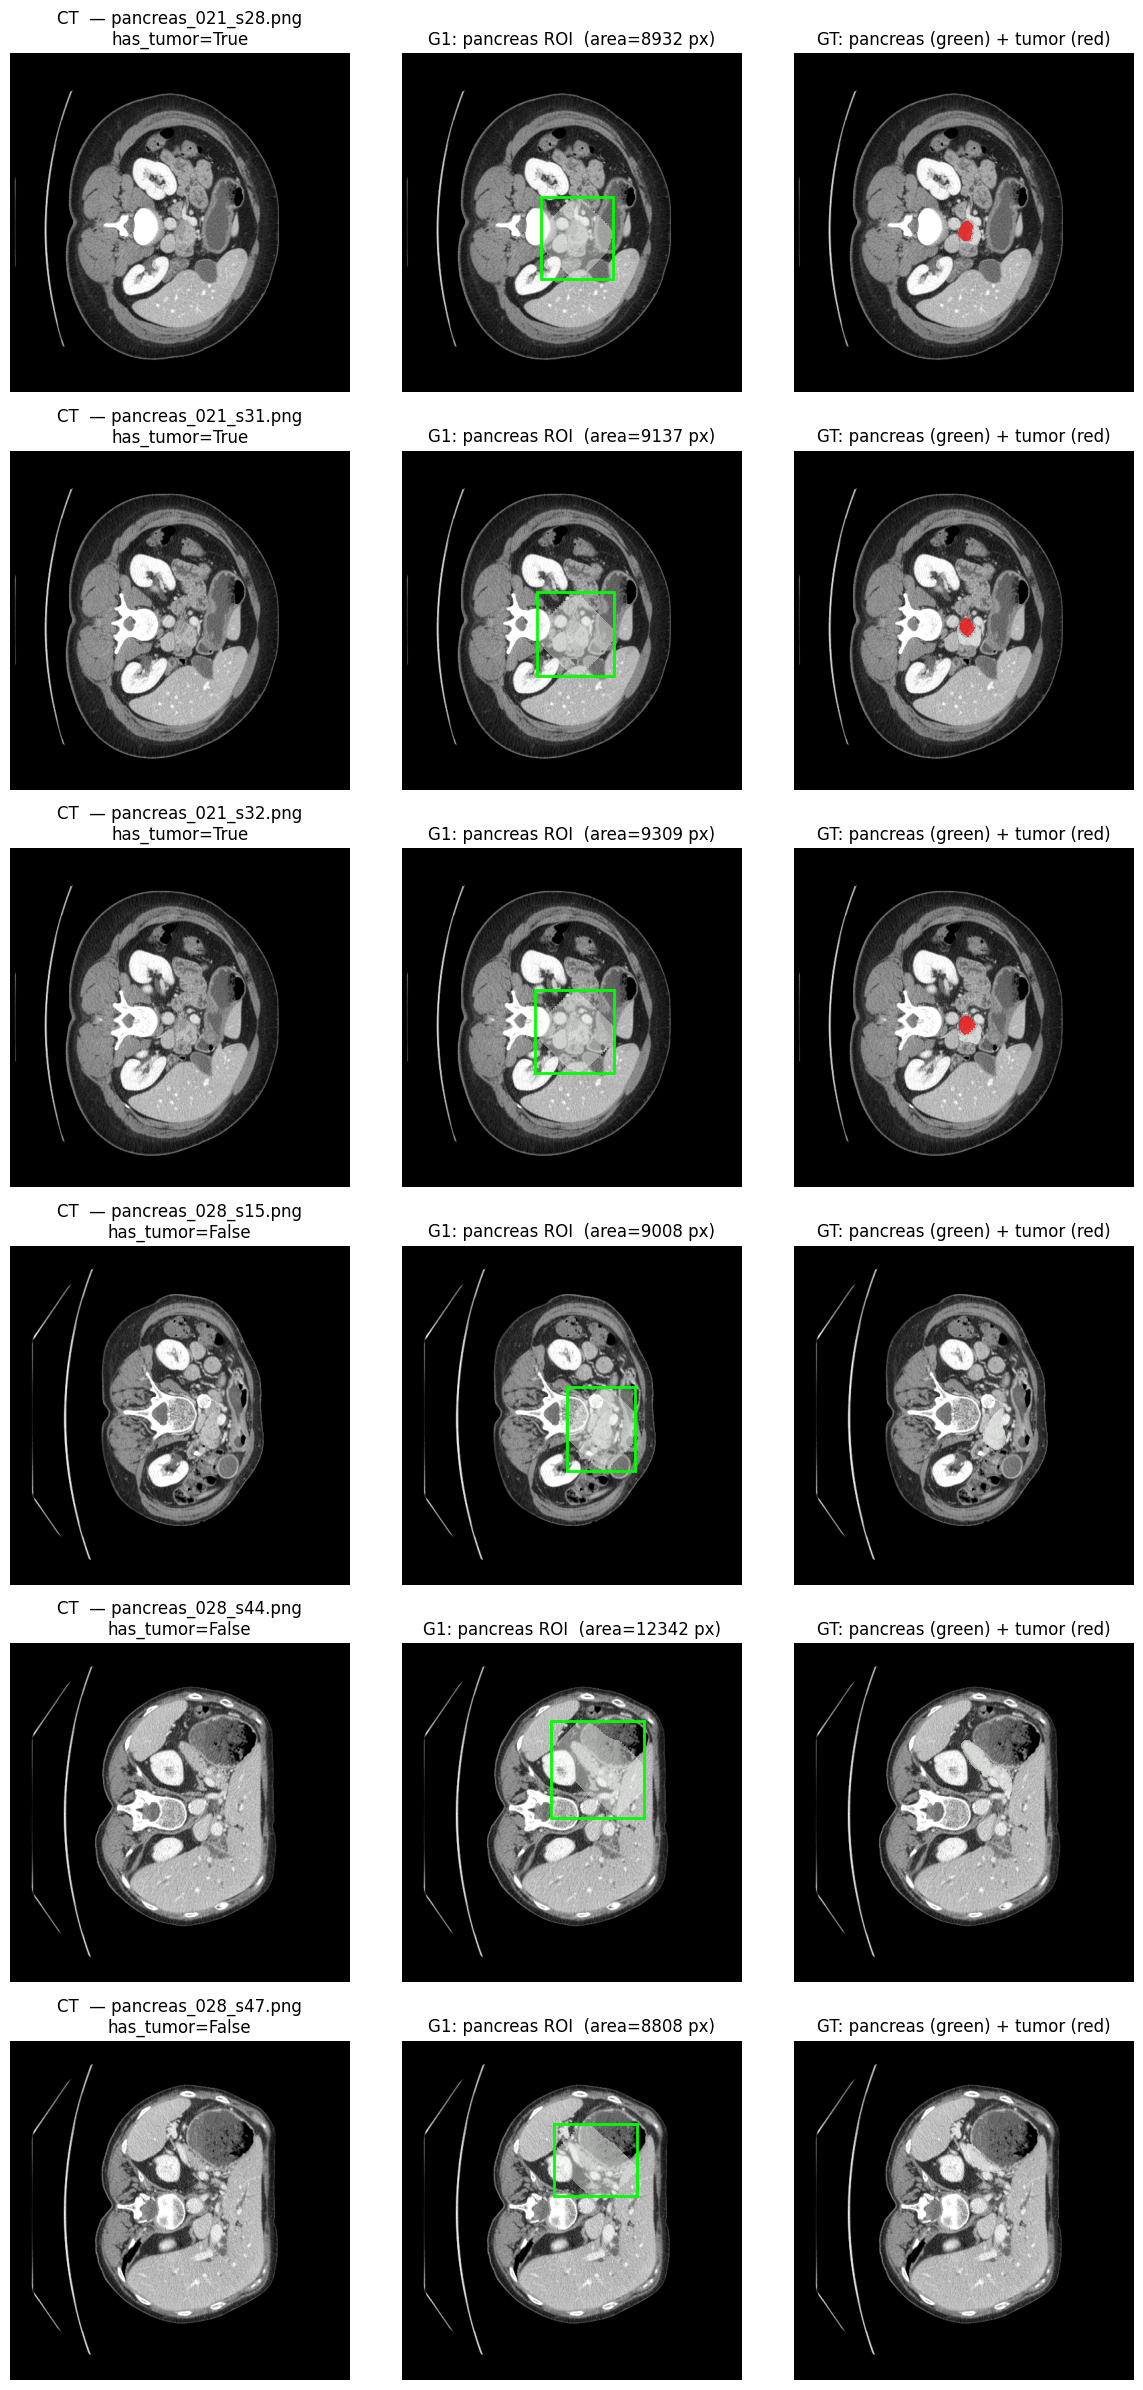

In [4]:
with open(config.MSD_TEST_JSON) as f:
    test_meta = json.load(f)

# Mix tumor-present / tumor-absent
def _has_tumor(file_name):
    m = np.array(Image.open(config.MSD_ROOT / file_name.replace('/images/', '/masks/')))
    if m.ndim == 3: m = m[..., 0]
    return int((m == 2).sum()) > 25

present = [i for i in test_meta['images'] if _has_tumor(i['file_name'])][:3]
absent  = [i for i in test_meta['images'] if not _has_tumor(i['file_name'])][:3]
picks = present + absent

fig, axes = plt.subplots(len(picks), 3, figsize=(12, 4 * len(picks)))
for row, info in enumerate(picks):
    img_path = config.MSD_ROOT / info['file_name']
    image = medsam.load_image(str(img_path))
    pmask, pbbox = pancreas_roi.infer_pancreas(image, dilation_px=config.PANCREAS_DILATION_PX)

    axes[row, 0].imshow(image, cmap='gray')
    axes[row, 0].set_title(f"CT  — {Path(info['file_name']).name}\nhas_tumor={_has_tumor(info['file_name'])}")
    axes[row, 0].axis('off')

    axes[row, 1].imshow(image, cmap='gray')
    axes[row, 1].imshow(np.ma.masked_where(pmask == 0, pmask), cmap='Greens', alpha=0.4)
    if pbbox is not None:
        x1, y1, x2, y2 = pbbox
        axes[row, 1].add_patch(plt.Rectangle((x1, y1), x2 - x1, y2 - y1, fill=False, edgecolor='lime', lw=2))
    axes[row, 1].set_title(f"G1: pancreas ROI  (area={int(pmask.sum())} px)")
    axes[row, 1].axis('off')

    gt_mask = np.array(Image.open(config.MSD_ROOT / info['file_name'].replace('/images/', '/masks/')))
    if gt_mask.ndim == 3: gt_mask = gt_mask[..., 0]
    axes[row, 2].imshow(image, cmap='gray')
    axes[row, 2].imshow(np.ma.masked_where(gt_mask != 1, gt_mask), cmap='Greens', alpha=0.5)
    axes[row, 2].imshow(np.ma.masked_where(gt_mask != 2, gt_mask), cmap='autumn', alpha=0.7)
    axes[row, 2].set_title("GT: pancreas (green) + tumor (red)")
    axes[row, 2].axis('off')
plt.tight_layout(); plt.show()

## 4. Calibrer le seuil τ sur le split val

On exécute **DINO + ROI pancréas** sur les 100 images val, on récupère le score max qui survit au filtre, puis on balaie τ et on choisit celui qui maximise F1 (tumor/no-tumor comme classification binaire).

Le résultat écrase `config.TUMOR_DIFF_THRESHOLD` pour la suite de la session.

In [5]:
calib = calibrate.calibrate_threshold(
    val_json=config.MSD_ROOT / 'val.json',
    use_pancreas_roi=True,
    n=None,
    n_thresholds=60,
)
print(f'optimal τ          = {calib.threshold:.4f}')
print(f'F1 @τ              = {calib.f1:.3f}')
print(f'sensitivity / spec = {calib.sensitivity:.3f} / {calib.specificity:.3f}')
print(f'TP/FP/TN/FN        = {calib.tp}/{calib.fp}/{calib.tn}/{calib.fn}')

# Apply to config for the rest of the notebook
config.TUMOR_DIFF_THRESHOLD = calib.threshold

# Persist to Drive so other runs can re-use it
calibrate.save_calibration(calib, config.AGENT_RESULTS_DIR / 'calibration.json')
print('saved calibration →', config.AGENT_RESULTS_DIR / 'calibration.json')

calibrate:   0%|          | 0/100 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/mmengine/optim/optimizer/zero_optimizer.py:11: DeprecationWarning: `TorchScript` support for functional optimizers is deprecated and will be removed in a future PyTorch release. Consider using the `torch.compile` optimizer instead.
  from torch.distributed.optim import \
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

...

noun_phrases: ['tumor']


/usr/local/lib/python3.12/dist-packages/mmcv/cnn/bricks/transformer.py:524: UserWarning: position encoding of key ismissing in MultiheadAttention.
  warnings.warn(f'position encoding of key is'
[nltk_data] Downloading package punkt to ~/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     ~/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!


noun_phrases: ['tumor']


/usr/local/lib/python3.12/dist-packages/mmcv/cnn/bricks/transformer.py:524: UserWarning: position encoding of key ismissing in MultiheadAttention.
  warnings.warn(f'position encoding of key is'


optimal τ          = 0.0000
F1 @τ              = 0.750
sensitivity / spec = 1.000 / 0.000
TP/FP/TN/FN        = 60/40/0/0
saved calibration → /content/INF8225_Projet/data/agent_results_msd/calibration.json


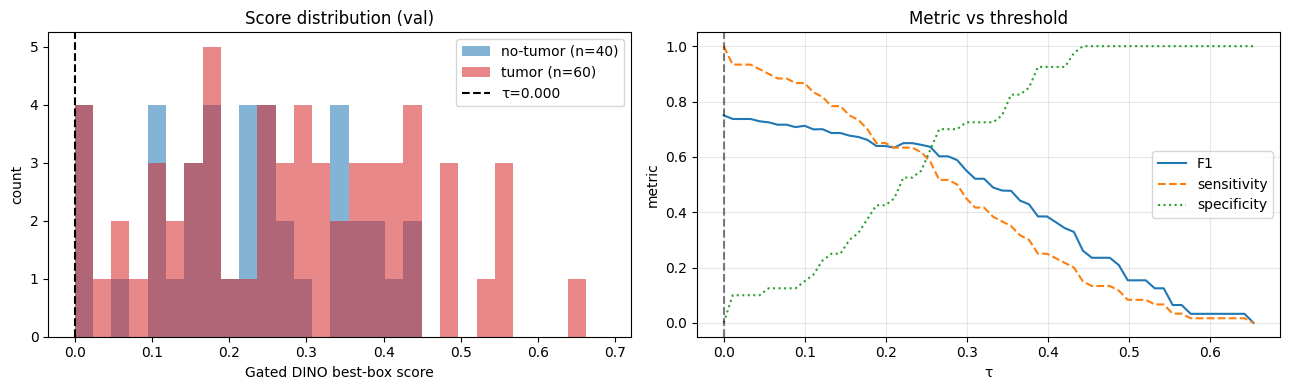

In [6]:
# Score distribution + F1 vs τ curve
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

bins = np.linspace(0, max(max(calib.scores_pos or [0.01]), max(calib.scores_neg or [0.01])) * 1.05, 30)
axes[0].hist(calib.scores_neg, bins=bins, alpha=0.55, label=f'no-tumor (n={len(calib.scores_neg)})', color='tab:blue')
axes[0].hist(calib.scores_pos, bins=bins, alpha=0.55, label=f'tumor (n={len(calib.scores_pos)})', color='tab:red')
axes[0].axvline(calib.threshold, color='k', ls='--', label=f'τ={calib.threshold:.3f}')
axes[0].set_xlabel('Gated DINO best-box score'); axes[0].set_ylabel('count')
axes[0].set_title('Score distribution (val)')
axes[0].legend()

axes[1].plot(calib.thresholds, calib.f1_curve, label='F1')
axes[1].plot(calib.thresholds, calib.sens_curve, label='sensitivity', ls='--')
axes[1].plot(calib.thresholds, calib.spec_curve, label='specificity', ls=':')
axes[1].axvline(calib.threshold, color='k', ls='--', alpha=0.5)
axes[1].set_xlabel('τ'); axes[1].set_ylabel('metric'); axes[1].set_title('Metric vs threshold')
axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 5. Démo visuelle gatée vs baseline

On prend les 3 tumeurs + 3 non-tumeurs de la section 3, et on compare :
- **Baseline** : DINO → top-1 → MedSAM
- **Gated** : G1 + G2 + G3 (seuil calibré)

[nltk_data] Downloading package punkt to ~/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     ~/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!


noun_phrases: ['tumor']


/usr/local/lib/python3.12/dist-packages/mmcv/cnn/bricks/transformer.py:524: UserWarning: position encoding of key ismissing in MultiheadAttention.
  warnings.warn(f'position encoding of key is'
/content/INF8225_Projet/MedSAM/segment_anything/build_sam.py:144: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where y

noun_phrases: ['tumor']


/usr/local/lib/python3.12/dist-packages/mmcv/cnn/bricks/transformer.py:524: UserWarning: position encoding of key ismissing in MultiheadAttention.
  warnings.warn(f'position encoding of key is'
[nltk_data] Downloading package punkt to ~/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     ~/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!


...

/usr/local/lib/python3.12/dist-packages/mmcv/cnn/bricks/transformer.py:524: UserWarning: position encoding of key ismissing in MultiheadAttention.
  warnings.warn(f'position encoding of key is'
[nltk_data] Downloading package punkt to ~/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     ~/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!


noun_phrases: ['tumor']


/usr/local/lib/python3.12/dist-packages/mmcv/cnn/bricks/transformer.py:524: UserWarning: position encoding of key ismissing in MultiheadAttention.
  warnings.warn(f'position encoding of key is'
[nltk_data] Downloading package punkt to ~/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     ~/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!


noun_phrases: ['tumor']


/usr/local/lib/python3.12/dist-packages/mmcv/cnn/bricks/transformer.py:524: UserWarning: position encoding of key ismissing in MultiheadAttention.
  warnings.warn(f'position encoding of key is'


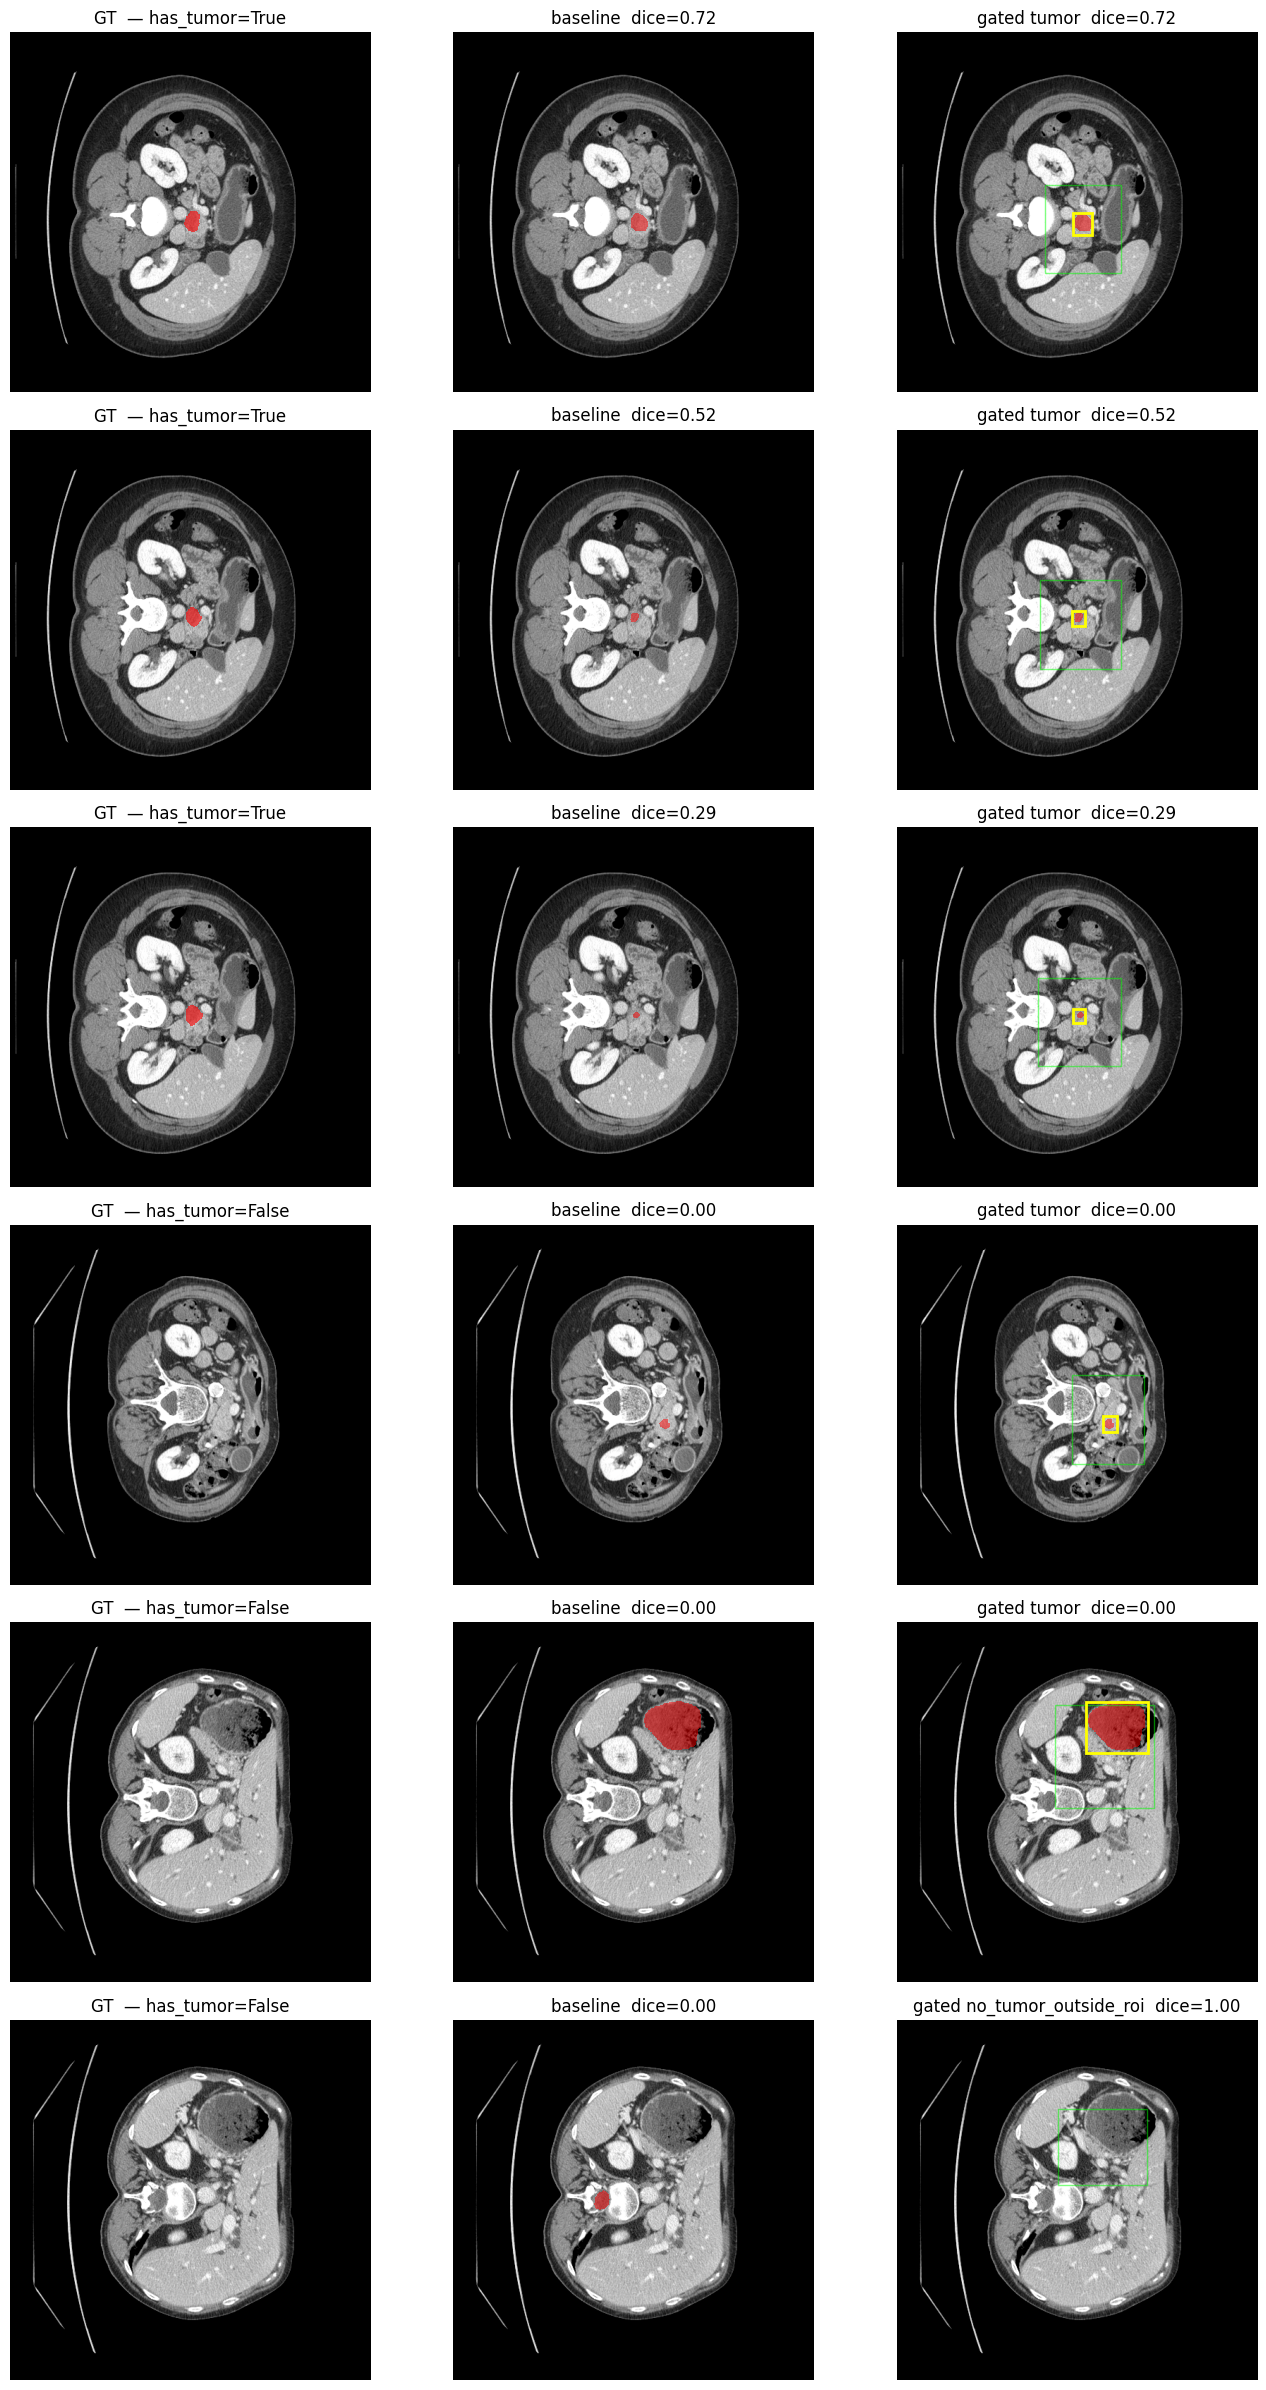

In [7]:
fig, axes = plt.subplots(len(picks), 3, figsize=(14, 4 * len(picks)))

for row, info in enumerate(picks):
    img_path = config.MSD_ROOT / info['file_name']
    image = medsam.load_image(str(img_path))
    has_tumor = _has_tumor(info['file_name'])
    gt_mask = np.array(Image.open(config.MSD_ROOT / info['file_name'].replace('/images/', '/masks/')))
    if gt_mask.ndim == 3: gt_mask = gt_mask[..., 0]
    gt_tumor = (gt_mask == 2).astype(np.uint8)

    # Baseline
    bmask, bscore = eval_improved._baseline_oneshot(str(img_path), config.DEFAULT_DINO_TEXT)

    # Gated
    res = gating.infer_gated(str(img_path), use_pancreas_roi=True, use_vlm_verify=False,
                              use_dual_prompt=False, score_threshold=calib.threshold)

    # (a) CT + GT tumor
    axes[row, 0].imshow(image, cmap='gray')
    axes[row, 0].imshow(np.ma.masked_where(gt_tumor == 0, gt_tumor), cmap='autumn', alpha=0.6)
    axes[row, 0].set_title(f"GT  — has_tumor={has_tumor}"); axes[row, 0].axis('off')

    # (b) Baseline prediction
    axes[row, 1].imshow(image, cmap='gray')
    if bmask.sum() > 0:
        axes[row, 1].imshow(np.ma.masked_where(bmask == 0, bmask), cmap='autumn', alpha=0.5)
    from agentic.dino_gemini_msd.metrics import dice as _dice
    axes[row, 1].set_title(f"baseline  dice={_dice(bmask, gt_tumor):.2f}")
    axes[row, 1].axis('off')

    # (c) Gated prediction
    axes[row, 2].imshow(image, cmap='gray')
    if res.pancreas_bbox is not None:
        x1, y1, x2, y2 = res.pancreas_bbox
        axes[row, 2].add_patch(plt.Rectangle((x1, y1), x2-x1, y2-y1, fill=False, edgecolor='lime', lw=1, alpha=0.5))
    if res.selected_box is not None:
        x1, y1, x2, y2 = res.selected_box
        axes[row, 2].add_patch(plt.Rectangle((x1, y1), x2-x1, y2-y1, fill=False, edgecolor='yellow', lw=2))
    if res.mask.sum() > 0:
        axes[row, 2].imshow(np.ma.masked_where(res.mask == 0, res.mask), cmap='autumn', alpha=0.5)
    axes[row, 2].set_title(f"gated {res.decision}  dice={_dice(res.mask, gt_tumor):.2f}")
    axes[row, 2].axis('off')

plt.tight_layout(); plt.show()

## 6. Ablation quantitative sur test

On évalue jusqu'à 6 configurations sur les 100 images test :

| Config                   | G1 | G3 τ     | Dual-prompt | VLM |
|--------------------------|----|----------|-------------|-----|
| `baseline`               | ✗  | -        | ✗           | ✗   |
| `+G1 pancreas ROI`       | ✓  | 0        | ✗           | ✗   |
| `+G1+G3 threshold`       | ✓  | calibré  | ✗           | ✗   |
| `+G1+G3+dual_prompt`     | ✓  | calibré  | ✓           | ✗   |
| `+G1+G3+VLM`             | ✓  | calibré  | ✗           | ✓   |
| `+G1+G3+dual+VLM`        | ✓  | calibré  | ✓           | ✓   |

- **Dual-prompt** : relance DINO avec `["normal pancreas tissue", "bowel gas", "abdominal organ"]` et soustrait `0.5 · max_distracteur` du score tumor → tue les candidats qui ressemblent autant à du distracteur qu'à de la tumeur.
- **VLM** : Gemini regarde le crop du candidat top-1 survivant ; si son verdict est `is_tumor=False`, on rejette. ~100 appels max par config activée. Nécessite `GEMINI_API_KEY` dans les Secrets Colab.

Tu peux désactiver individuellement via les flags `INCLUDE_DUAL_PROMPT`, `INCLUDE_VLM`, `INCLUDE_BOTH` dans la cellule suivante.

In [13]:
INCLUDE_DUAL_PROMPT = True    # relance DINO avec ["normal pancreas tissue", "bowel gas", "abdominal organ"] et soustrait le max distracteur
INCLUDE_VLM         = True    # Gemini vérifie sémantiquement le crop top-1 — nécessite GEMINI_API_KEY
INCLUDE_BOTH        = True    # dual-prompt ET VLM combinés
N_TEST = None                  # None = les 100 images du split test

import json as _json
from datetime import datetime as _dt

def _gated(name, **kw):
    print(f'\n=== {name} ===')
    return eval_improved.run_gated(
        coco_json=config.MSD_TEST_JSON,
        n=N_TEST,
        score_threshold=calib.threshold,
        pancreas_ckpt=str(config.PANCREAS_CKPT),
        **kw,
    )

ablation = {}
print('=== baseline ===')
ablation['baseline'] = eval_improved.run_baseline(coco_json=config.MSD_TEST_JSON, n=N_TEST)
ablation['+G1 pancreas ROI'] = _gated('+G1 pancreas ROI',
    use_pancreas_roi=True, use_vlm_verify=False, use_dual_prompt=False)
ablation['+G1+G3 threshold'] = _gated('+G1+G3 threshold',
    use_pancreas_roi=True, use_vlm_verify=False, use_dual_prompt=False)

if INCLUDE_DUAL_PROMPT:
    ablation['+G1+G3+dual_prompt'] = _gated('+G1+G3+dual_prompt',
        use_pancreas_roi=True, use_vlm_verify=False, use_dual_prompt=True)

if INCLUDE_VLM:
    ablation['+G1+G3+VLM'] = _gated('+G1+G3+VLM',
        use_pancreas_roi=True, use_vlm_verify=True, use_dual_prompt=False)

if INCLUDE_BOTH:
    ablation['+G1+G3+dual+VLM'] = _gated('+G1+G3+dual+VLM',
        use_pancreas_roi=True, use_vlm_verify=True, use_dual_prompt=True)

# Persist to Drive
save_dir = config.AGENT_RESULTS_DIR
save_dir.mkdir(parents=True, exist_ok=True)
ts = _dt.now().strftime('%Y-%m-%dT%H-%M-%S')
for name, (df, summ) in ablation.items():
    safe = name.replace(' ', '_').replace('+', 'p')
    df.to_csv(save_dir / f'ablation_{ts}_{safe}.csv', index=False)
with open(save_dir / f'ablation_{ts}_summary.json', 'w') as f:
    _json.dump({name: summ.to_dict() for name, (_, summ) in ablation.items()}, f, indent=2)
print(f'\nsaved → {save_dir / f"ablation_{ts}_summary.json"}')

summary_rows = []
for name, (df, summ) in ablation.items():
    summary_rows.append({'config': name, **summ.to_dict()})
summary_df = pd.DataFrame(summary_rows)
summary_df

=== baseline ===


baseline:   0%|          | 0/100 [00:00<?, ?it/s]

noun_phrases: ['tumor']


[nltk_data] Downloading package punkt to ~/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     ~/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
/usr/local/lib/python3.12/dist-packages/mmcv/cnn/bricks/transformer.py:524: UserWarning: position encoding of key ismissing in MultiheadAttention.
  warnings.warn(f'position encoding of key is'
[nltk_data] Downloading package punkt to ~/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     ~/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!


noun_phrases: ['tumor']


...

[nltk_data] Downloading package punkt to ~/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     ~/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!


noun_phrases: ['bowel gas']


[nltk_data] Downloading package punkt to ~/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     ~/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!


noun_phrases: ['abdominal organ']

saved → /content/INF8225_Projet/data/agent_results_msd/ablation_2026-04-23T04-34-33_summary.json


,config,n,n_tumor,n_no_tumor,sensitivity,specificity,precision,f1,dice_tumor_present_mean,dice_all_mean,tp,fp,tn,fn
0,baseline,100,60,40,0.983333,0.175,0.641304,0.776316,0.472667,0.353600,59,33,7,1
1,+G1 pancreas ROI,100,60,40,0.916667,0.300,0.662651,0.769231,0.450708,0.390425,55,28,12,5
2,+G1+G3 threshold,100,60,40,0.916667,0.300,0.662651,0.769231,0.450708,0.390425,55,28,12,5
3,+G1+G3+dual_prompt,100,60,40,0.916667,0.350,0.679012,0.780142,0.415508,0.389305,55,26,14,5
4,+G1+G3+VLM,100,60,40,0.733333,0.500,0.687500,0.709677,0.350179,0.410108,44,20,20,16
5,+G1+G3+dual+VLM,100,60,40,0.750000,0.575,0.725806,0.737705,0.333314,0.429988,45,17,23,15


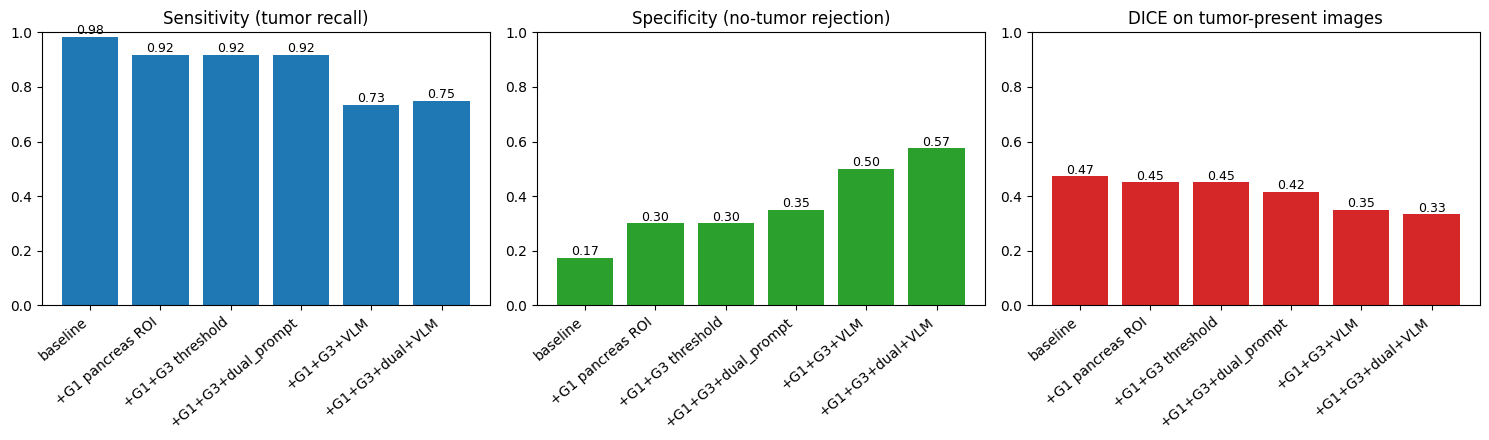

In [14]:
# Metric comparison bars — dynamique, supporte n configs
fig, axes = plt.subplots(1, 3, figsize=(max(15, 2.5 * len(summary_df)), 4.5))

x = np.arange(len(summary_df))
rot = 25 if len(summary_df) <= 5 else 40
axes[0].bar(x, summary_df['sensitivity'], color='tab:blue')
axes[0].set_ylim(0, 1); axes[0].set_title('Sensitivity (tumor recall)')
axes[0].set_xticks(x); axes[0].set_xticklabels(summary_df['config'], rotation=rot, ha='right')

axes[1].bar(x, summary_df['specificity'], color='tab:green')
axes[1].set_ylim(0, 1); axes[1].set_title('Specificity (no-tumor rejection)')
axes[1].set_xticks(x); axes[1].set_xticklabels(summary_df['config'], rotation=rot, ha='right')

axes[2].bar(x, summary_df['dice_tumor_present_mean'], color='tab:red')
axes[2].set_ylim(0, 1); axes[2].set_title('DICE on tumor-present images')
axes[2].set_xticks(x); axes[2].set_xticklabels(summary_df['config'], rotation=rot, ha='right')

for ax, col in zip(axes, ['sensitivity', 'specificity', 'dice_tumor_present_mean']):
    for xi, v in enumerate(summary_df[col]):
        ax.text(xi, v + 0.01, f'{v:.2f}', ha='center', fontsize=9)
plt.tight_layout(); plt.show()

best gated config by F1: +G1+G3+dual_prompt


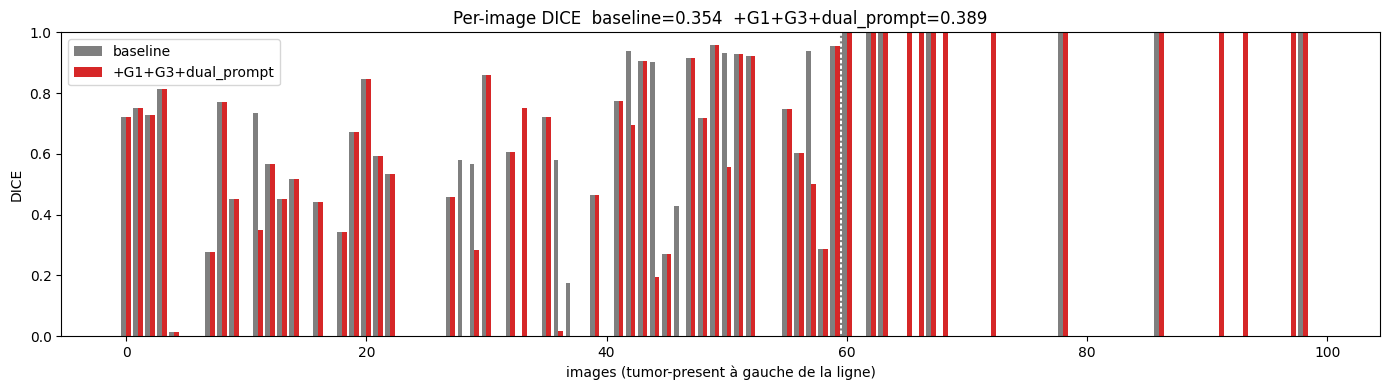

In [15]:
# Per-image DICE comparison: baseline vs best-F1 gated config
best_name = max(
    (name for name in ablation if name != 'baseline'),
    key=lambda n: ablation[n][1].f1,
)
print(f'best gated config by F1: {best_name}')

baseline_df = ablation['baseline'][0].set_index('file_name')
best_df     = ablation[best_name][0].set_index('file_name')
cmp = baseline_df[['has_tumor', 'dice']].rename(columns={'dice': 'dice_baseline'}).join(
    best_df[['dice']].rename(columns={'dice': 'dice_best'})
).reset_index()
cmp['dice_delta'] = cmp['dice_best'] - cmp['dice_baseline']
cmp = cmp.sort_values('has_tumor', ascending=False).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(14, 4))
idx = np.arange(len(cmp))
ax.bar(idx - 0.2, cmp['dice_baseline'], width=0.4, label='baseline', color='tab:gray')
ax.bar(idx + 0.2, cmp['dice_best'], width=0.4, label=best_name, color='tab:red')
ax.axvline(cmp['has_tumor'].sum() - 0.5, color='k', ls=':', alpha=0.5)
ax.set_xlabel('images (tumor-present à gauche de la ligne)')
ax.set_ylabel('DICE')
ax.set_title(f"Per-image DICE  baseline={cmp['dice_baseline'].mean():.3f}  {best_name}={cmp['dice_best'].mean():.3f}")
ax.legend(); ax.set_ylim(0, 1)
plt.tight_layout(); plt.show()

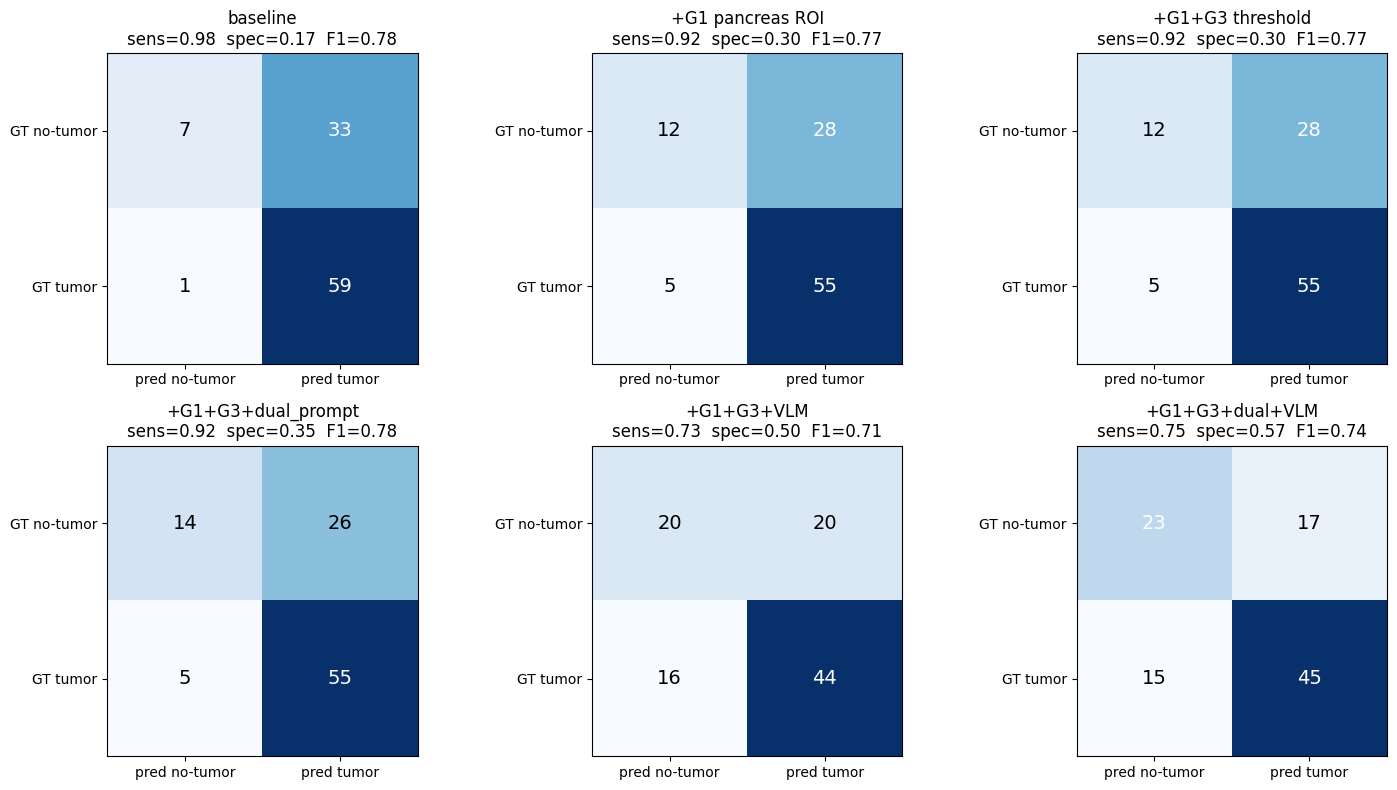

In [16]:
# Confusion matrices per configuration — grid layout pour n configs
from itertools import product
n_cfg = len(ablation)
ncols = min(n_cfg, 3)
nrows = (n_cfg + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
axes = np.atleast_2d(axes).ravel()
for idx, (name, (_, summ)) in enumerate(ablation.items()):
    ax = axes[idx]
    M_ = np.array([[summ.tn, summ.fp], [summ.fn, summ.tp]])
    ax.imshow(M_, cmap='Blues')
    for i, j in product(range(2), range(2)):
        ax.text(j, i, str(M_[i, j]), ha='center', va='center', fontsize=14,
                color='white' if M_[i, j] > M_.max() / 2 else 'black')
    ax.set_xticks([0, 1]); ax.set_xticklabels(['pred no-tumor', 'pred tumor'])
    ax.set_yticks([0, 1]); ax.set_yticklabels(['GT no-tumor', 'GT tumor'])
    ax.set_title(f"{name}\nsens={summ.sensitivity:.2f}  spec={summ.specificity:.2f}  F1={summ.f1:.2f}")
for idx in range(n_cfg, len(axes)):
    axes[idx].axis('off')
plt.tight_layout(); plt.show()

## 7. Cas où la gating fait la différence

On extrait les 4 images où `dice_gated - dice_baseline` est maximal (gating rejette un faux positif, ou recale la box).

[nltk_data] Downloading package punkt to ~/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     ~/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!


noun_phrases: ['tumor']


/usr/local/lib/python3.12/dist-packages/mmcv/cnn/bricks/transformer.py:524: UserWarning: position encoding of key ismissing in MultiheadAttention.
  warnings.warn(f'position encoding of key is'
[nltk_data] Downloading package punkt to ~/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     ~/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!


noun_phrases: ['tumor']


/usr/local/lib/python3.12/dist-packages/mmcv/cnn/bricks/transformer.py:524: UserWarning: position encoding of key ismissing in MultiheadAttention.
  warnings.warn(f'position encoding of key is'
[nltk_data] Downloading package punkt to ~/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     ~/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!


...

noun_phrases: ['normal pancreas tissue']


[nltk_data] Downloading package punkt to ~/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     ~/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!


noun_phrases: ['bowel gas']


[nltk_data] Downloading package punkt to ~/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     ~/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!


noun_phrases: ['abdominal organ']


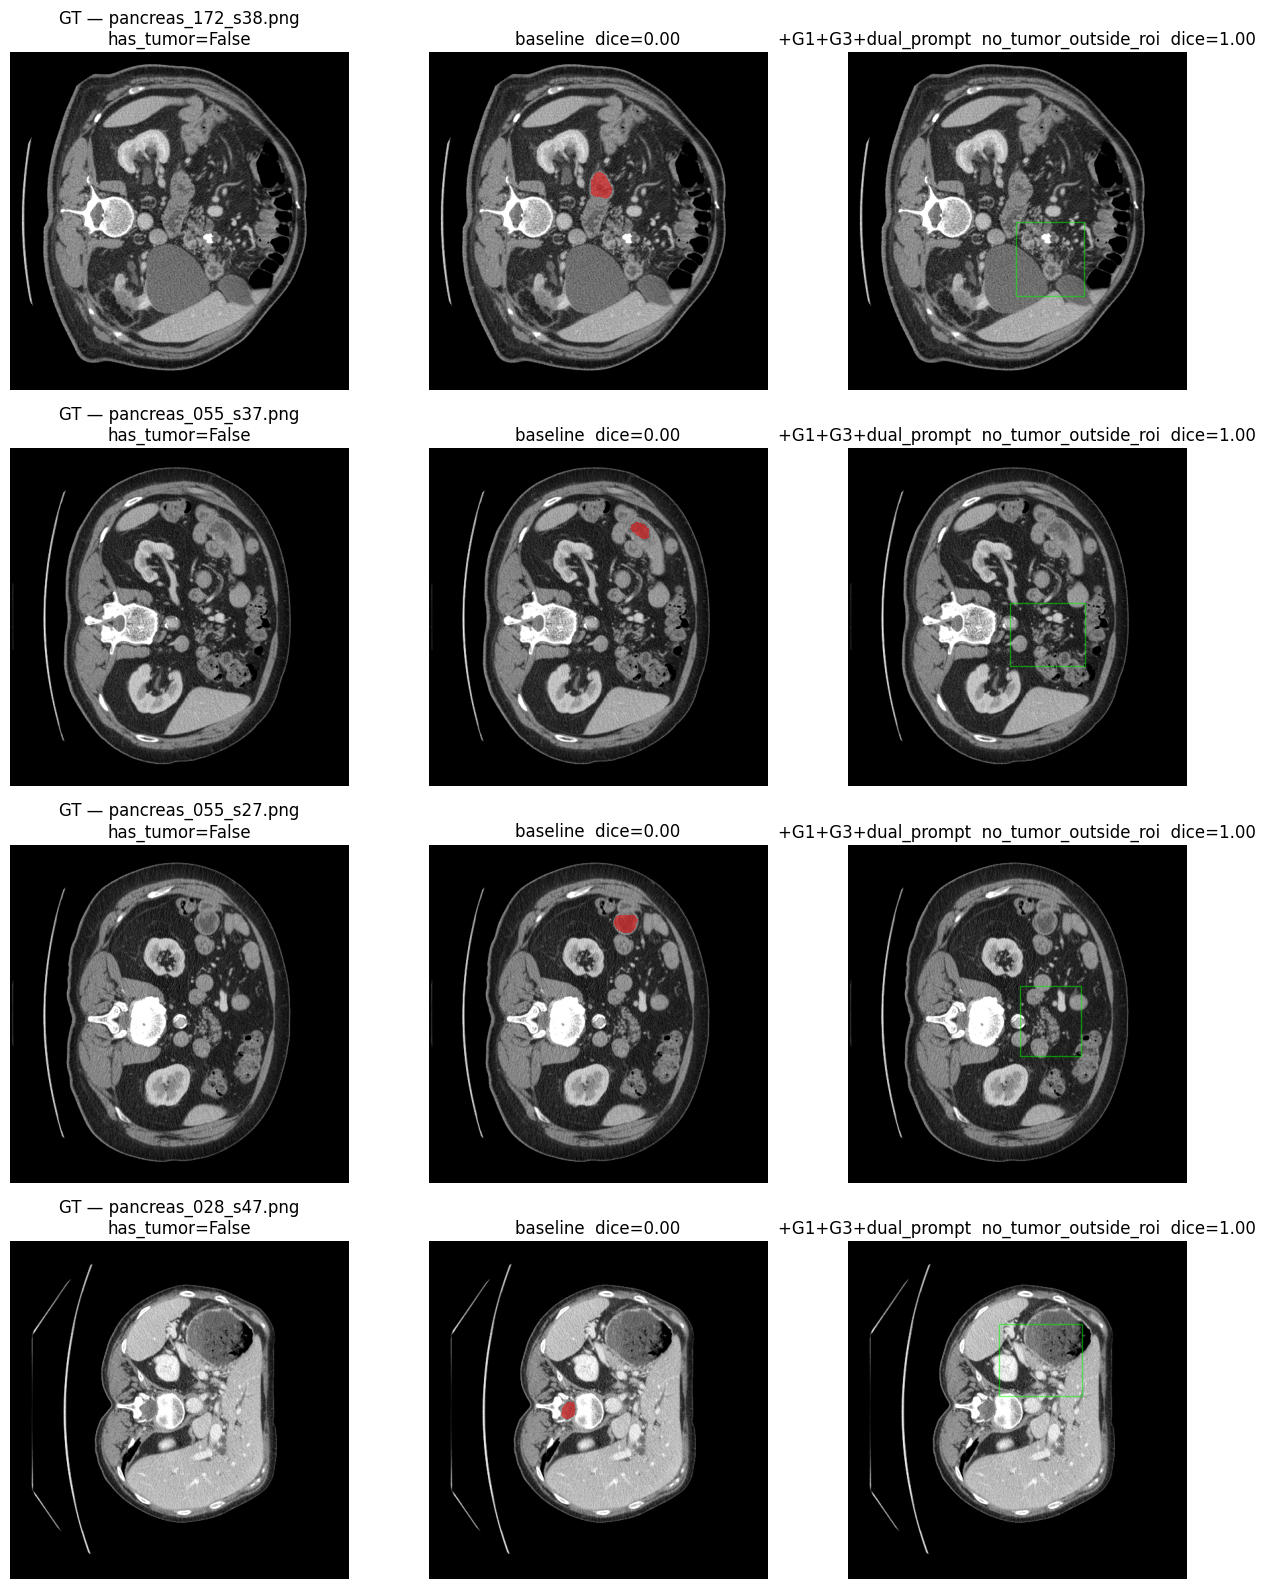

In [17]:
# Visualisation des 4 images où la config gagnante apporte le plus de DICE vs baseline
picks_delta = cmp.nlargest(4, 'dice_delta')['file_name'].tolist()

# Match best config name to gating flags
BEST_FLAGS = {
    '+G1 pancreas ROI':    dict(use_pancreas_roi=True, use_vlm_verify=False, use_dual_prompt=False),
    '+G1+G3 threshold':    dict(use_pancreas_roi=True, use_vlm_verify=False, use_dual_prompt=False),
    '+G1+G3+dual_prompt':  dict(use_pancreas_roi=True, use_vlm_verify=False, use_dual_prompt=True),
    '+G1+G3+VLM':          dict(use_pancreas_roi=True, use_vlm_verify=True,  use_dual_prompt=False),
    '+G1+G3+dual+VLM':     dict(use_pancreas_roi=True, use_vlm_verify=True,  use_dual_prompt=True),
}
flags = BEST_FLAGS.get(best_name, dict(use_pancreas_roi=True, use_vlm_verify=False, use_dual_prompt=False))

fig, axes = plt.subplots(len(picks_delta), 3, figsize=(13, 4 * len(picks_delta)))
if len(picks_delta) == 1:
    axes = axes[None, :]
for row, fn in enumerate(picks_delta):
    img_path = config.MSD_ROOT / fn
    image = medsam.load_image(str(img_path))
    gt_mask = np.array(Image.open(config.MSD_ROOT / fn.replace('/images/', '/masks/')))
    if gt_mask.ndim == 3: gt_mask = gt_mask[..., 0]
    gt_tumor = (gt_mask == 2).astype(np.uint8)

    bmask, _ = eval_improved._baseline_oneshot(str(img_path), config.DEFAULT_DINO_TEXT)
    res = gating.infer_gated(str(img_path), score_threshold=calib.threshold, **flags)

    axes[row, 0].imshow(image, cmap='gray')
    axes[row, 0].imshow(np.ma.masked_where(gt_tumor == 0, gt_tumor), cmap='autumn', alpha=0.6)
    axes[row, 0].set_title(f"GT — {Path(fn).name}\nhas_tumor={gt_tumor.sum() > 0}"); axes[row, 0].axis('off')

    axes[row, 1].imshow(image, cmap='gray')
    if bmask.sum() > 0:
        axes[row, 1].imshow(np.ma.masked_where(bmask == 0, bmask), cmap='autumn', alpha=0.5)
    axes[row, 1].set_title(f'baseline  dice={_dice(bmask, gt_tumor):.2f}'); axes[row, 1].axis('off')

    axes[row, 2].imshow(image, cmap='gray')
    if res.pancreas_bbox is not None:
        x1, y1, x2, y2 = res.pancreas_bbox
        axes[row, 2].add_patch(plt.Rectangle((x1, y1), x2-x1, y2-y1, fill=False, edgecolor='lime', lw=1, alpha=0.5))
    if res.mask.sum() > 0:
        axes[row, 2].imshow(np.ma.masked_where(res.mask == 0, res.mask), cmap='autumn', alpha=0.5)
    axes[row, 2].set_title(f'{best_name}  {res.decision}  dice={_dice(res.mask, gt_tumor):.2f}')
    axes[row, 2].axis('off')
plt.tight_layout(); plt.show()

## 8. (Optionnel) Gating branché sur l'agent Gemini

Quand la gate accepte une box, on la passe au `run_agent` habituel pour bénéficier du raffinement itératif. Quand la gate rejette, on économise tous les appels Gemini + MedSAM.

In [18]:
# Uncomment to run. Requires GEMINI_API_KEY in Colab Secrets.
from agentic.dino_gemini_msd.agent import run_agent
img_info = picks[0]  # first tumor image
state = run_agent(
    str(config.MSD_ROOT / img_info['file_name']),
    user_text='find the pancreatic tumor',
    use_gating=True,
    gating_kwargs={'score_threshold': calib.threshold, 'use_vlm_verify': False},
    persist=False,
)
print('stop_reason:', state.stop_reason)
print('# iterations:', len(state.iterations))
print('best iter dice:', state.best_iter().dice_vs_gt if state.best_iter() else None)

[nltk_data] Downloading package punkt to ~/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     ~/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!


noun_phrases: ['pancreatic tumor']


/usr/local/lib/python3.12/dist-packages/mmcv/cnn/bricks/transformer.py:524: UserWarning: position encoding of key ismissing in MultiheadAttention.
  warnings.warn(f'position encoding of key is'
[nltk_data] Downloading package punkt to ~/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     ~/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!


noun_phrases: ['pancreatic tumor']


/usr/local/lib/python3.12/dist-packages/mmcv/cnn/bricks/transformer.py:524: UserWarning: position encoding of key ismissing in MultiheadAttention.
  warnings.warn(f'position encoding of key is'


stop_reason: gemma_stop
# iterations: 1
best iter dice: None


## 9. Résumé — ce qui a bougé

| Problème initial | Solution appliquée | Porte |
|---|---|---|
| DINO hallucine hors pancréas | Filtre géométrique sur ROI UNet | G1+G2 |
| Negative prompts `no tumor` dégradent | Remplacés par score différentiel dual-prompt (optionnel) + vérif VLM | G2.5+G3 |
| Images sans tumeur mal gérées | Seuil τ calibré sur val → masque vide honnête | G3 |
| MedSAM segmente n'importe quoi | Box clippée à la bbox pancréas, mask AND-é avec ROI | G1 |
| Classifieur amont inefficace | Remplacé par la combinaison ROI + τ (signal global ineffficace, signal local gate-filtré efficace) | architecture |

**Checkpoints persistés dans Drive :**
- `work_dirs/pancreas_unet/best.pt` (UNet)
- `data/agent_results_msd/calibration.json` (τ et courbes)
- `data/agent_results_msd/ablation_*_*.csv` + `ablation_*_summary.json`